# Feature ladder (10% subset): core $\to$ +interface degree $\to$ +rSASA$_i$ $\to$ +Voronoi contact area

Twelve runs, a cumulative feature ladder $\times$ three seeds (7, 17, 27), on the 10% DockQ-bin-stratified
subset (`gate_run/subset_10pct_hdf5`), sharing one frozen target split (105 train / 12 val / 29 test targets,
`shared_target_splits.json`).

**This is the baseline ladder, run before two corrections now in flight:** the `rsasa` and `voronoi` rungs here
use `rsasa_i`, a per-decoy **graph-level average** rSASA$_i$ broadcast to every node, not a genuine per-residue
value; and there is no fifth "electrostatics" rung at all. A corrected 5-rung ladder (`rsasa_i_node` replacing
`rsasa_i`, plus a new `v_es` electrostatics rung) is running separately on both the 10% subset and the full
dataset. Treat every number below as a baseline to compare the corrected run against, not as the final result.

Figures use LaTeX Computer Modern, large labels, full borders and no titles, matching the project's other
analysis notebooks. Error bars and bands are **sample standard deviation across three seeds**, not confidence
intervals -- three seeds is a small basis for inference.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

GATE = Path.cwd() if (Path.cwd() / 'feature_ladder_10pct').is_dir() else Path.cwd() / 'gate_run'
ROOT = GATE / 'feature_ladder_10pct'
EXPORT = GATE / 'feature_ladder_10pct_analysis'; EXPORT.mkdir(exist_ok=True)

RUNGS = ['core', 'degree', 'rsasa', 'voronoi']
SEEDS = [7, 17, 27]
RUNG_LABEL = {'core': 'core', 'degree': '+degree', 'rsasa': '+rSASA$_i$ (avg)', 'voronoi': '+Voronoi area'}
RUNG_COLOR = {'core': '#0072B2', 'degree': '#56B4E9', 'rsasa': '#009E73', 'voronoi': '#D55E00'}

mpl.rcParams.update({'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern Roman'],
    'mathtext.fontset': 'cm', 'axes.labelsize': 23, 'xtick.labelsize': 17, 'ytick.labelsize': 17,
    'legend.fontsize': 17, 'axes.spines.top': True, 'axes.spines.right': True, 'axes.linewidth': 1.1})

def save(fig, name):
    fig.savefig(EXPORT / (name + '.pdf'), bbox_inches='tight')
    fig.savefig(EXPORT / (name + '.png'), dpi=180, bbox_inches='tight')
    plt.show()

def run_dir(rung, seed):
    return ROOT / f'gat4_residual_{rung}_seed{seed}'

split = json.loads((ROOT / 'shared_target_splits.json').read_text())
n_train = len(split['splits']['train']['paths'])
n_val = len(split['splits']['val']['paths'])
n_test = len(split['splits']['test']['paths'])
print(f'Target split: {n_train} train / {n_val} val / {n_test} test (seed {split["seed"]}).')

history = []
for rung in RUNGS:
    for seed in SEEDS:
        df = pd.read_csv(run_dir(rung, seed) / 'loss_history.csv')
        df['rung'] = rung; df['seed'] = seed
        history.append(df)
history = pd.concat(history, ignore_index=True)

summary = pd.read_csv(ROOT / 'gat4_residual_core_seed7' / 'reconstruction_summary.csv').iloc[:0]
summaries = []
for rung in RUNGS:
    for seed in SEEDS:
        row = pd.read_csv(run_dir(rung, seed) / 'reconstruction_summary.csv').iloc[0].to_dict()
        row['rung'] = rung; row['seed'] = seed
        summaries.append(row)
summary = pd.DataFrame(summaries)

predictions = []
for rung in RUNGS:
    for seed in SEEDS:
        df = pd.read_csv(run_dir(rung, seed) / 'test_predictions.csv')
        df['rung'] = rung; df['seed'] = seed
        predictions.append(df)
predictions = pd.concat(predictions, ignore_index=True)

print(f'{len(history)} loss-history rows, {len(summary)} runs, {len(predictions)} test predictions loaded.')

Target split: 105 train / 12 val / 29 test (seed 5).
600 loss-history rows, 12 runs, 41478 test predictions loaded.


## Model selection

Checkpoints are selected on minimum validation `target_mse`. For each run, find that epoch and read off the
test-split `target_mse` logged at the *same* epoch (the test split is evaluated every epoch purely for
monitoring; it never influences checkpointing).

In [2]:
best_rows = []
for (rung, seed), g in history.groupby(['rung', 'seed']):
    best = g.loc[g.val_target_mse.idxmin()]
    best_rows.append(dict(rung=rung, seed=seed, best_epoch=int(best.epoch),
                           val_target_mse=best.val_target_mse, test_target_mse=best.test_target_mse,
                           test_target_rmse=best.test_target_rmse,
                           train_target_mse_at_end=g.iloc[-1].train_target_mse))
best = pd.DataFrame(best_rows)

macro_rho = []
for (rung, seed), g in predictions.groupby(['rung', 'seed']):
    per_target = g.groupby('target_id').apply(
        lambda t: spearmanr(t.true_target, t.predicted_target).statistic if t.true_target.nunique() > 1 else np.nan)
    macro_rho.append(dict(rung=rung, seed=seed, macro_rho=per_target.mean()))
best = best.merge(pd.DataFrame(macro_rho), on=['rung', 'seed'])
best.to_csv(EXPORT / 'best_epoch_per_run.csv', index=False)
display(best.round(4))
print(f'Selected epochs across the twelve runs: {sorted(best.best_epoch)}.')

/tmp/ipykernel_29141/2845022695.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_target = g.groupby('target_id').apply(
/tmp/ipykernel_29141/2845022695.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_target = g.groupby('target_id').apply(
/tmp/ipykernel_29141/2845022695.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a 

,rung,seed,best_epoch,val_target_mse,test_target_mse,test_target_rmse,train_target_mse_at_end,macro_rho
0,core,7,2,0.0724,0.0835,0.2889,0.0063,0.6052
1,core,17,2,0.0700,0.0897,0.2995,0.0071,0.5771
2,core,27,1,0.0678,0.0812,0.2850,0.0067,0.6141
3,degree,7,2,0.0629,0.0771,0.2777,0.0106,0.5834
4,degree,17,15,0.0540,0.0948,0.3079,0.0103,0.5505
5,degree,27,16,0.0577,0.0802,0.2832,0.0110,0.5982
6,rsasa,7,1,0.0647,0.0687,0.2622,0.0100,0.6657
7,rsasa,17,2,0.0602,0.0658,0.2564,0.0109,0.6884
8,rsasa,27,9,0.0574,0.0812,0.2850,0.0107,0.6489
9,voronoi,7,18,0.0594,0.0813,0.2851,0.0099,0.6485


Selected epochs across the twelve runs: [1, 1, 2, 2, 2, 2, 4, 6, 9, 15, 16, 18].


## The ladder: does each added feature help?

Bars are the three-seed mean with seed standard deviation; dots are the individual seed runs. Left panel is the
checkpoint-selection metric itself (lower is better); right panel is macro-averaged within-target Spearman
$\rho$ between true and predicted DockQ on the held-out test split (higher is better, scale-free, robust to
cross-target offset).

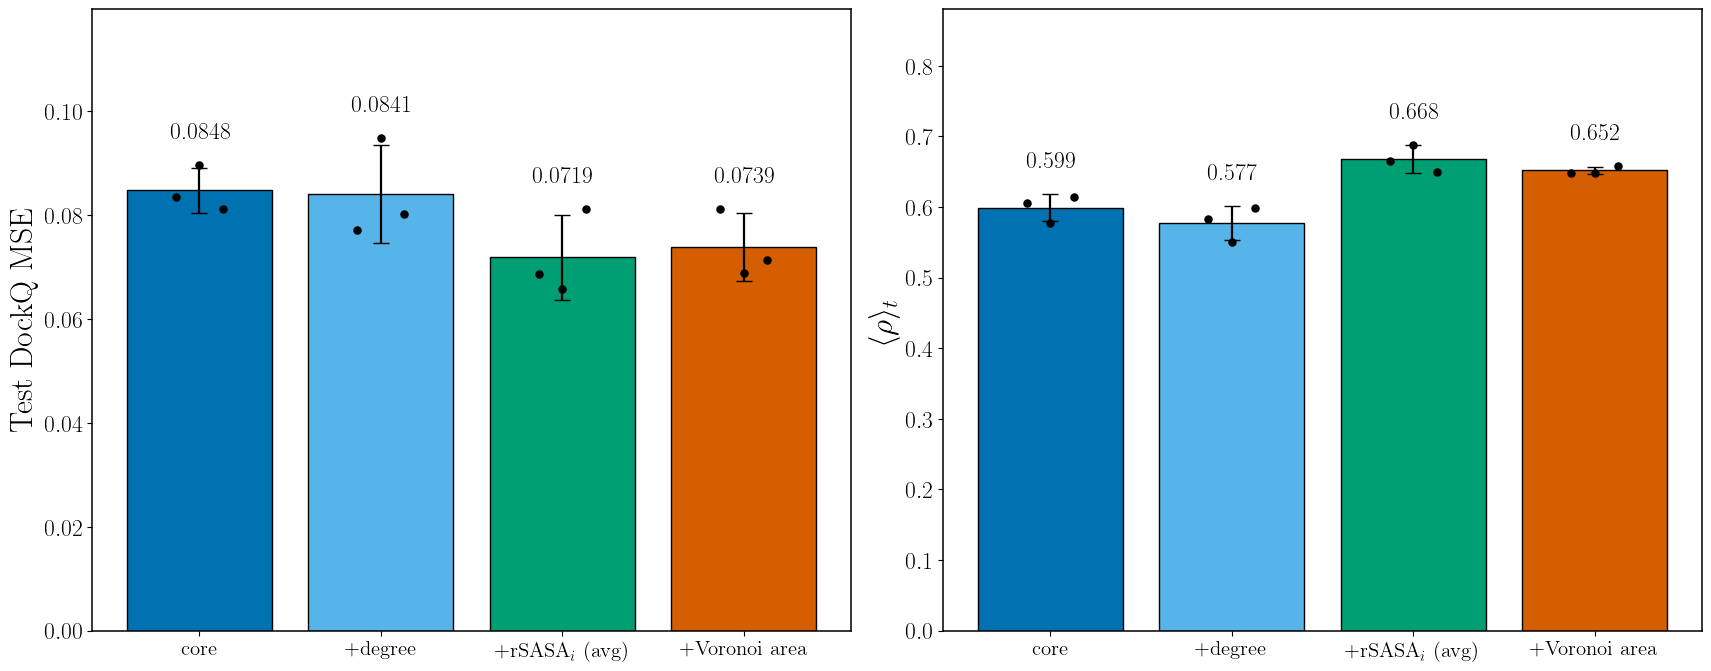

In [3]:
agg = best.groupby('rung').agg(mean_mse=('test_target_mse', 'mean'), sd_mse=('test_target_mse', 'std'),
                                mean_rho=('macro_rho', 'mean'), sd_rho=('macro_rho', 'std')).loc[RUNGS]

fig, axes = plt.subplots(1, 2, figsize=(17, 6.6), constrained_layout=True)
x = np.arange(len(RUNGS)); labels = [RUNG_LABEL[r] for r in RUNGS]
for ax, mean_col, sd_col, run_col, ylabel, fmt in [
        (axes[0], 'mean_mse', 'sd_mse', 'test_target_mse', 'Test DockQ MSE', '%.4f'),
        (axes[1], 'mean_rho', 'sd_rho', 'macro_rho', r'$\langle\rho\rangle_t$', '%.3f')]:
    values = agg[mean_col].to_numpy(); errors = agg[sd_col].to_numpy()
    top = (values + errors).max()
    ax.bar(x, values, color=[RUNG_COLOR[r] for r in RUNGS], edgecolor='black',
           yerr=errors, capsize=6, error_kw=dict(lw=1.6))
    for i, r in enumerate(RUNGS):
        seed_values = best.loc[best.rung == r, run_col].to_numpy()
        ax.scatter(i + np.linspace(-.13, .13, len(seed_values)), seed_values, color='black', s=26, zorder=6)
        ax.text(i, max(values[i] + errors[i], seed_values.max()) + .055 * top, fmt % values[i],
                ha='center', fontsize=17)
    ax.set_xticks(x, labels, fontsize=15); ax.set_ylabel(ylabel)
    ax.set_ylim(0, top * 1.28)
save(fig, 'ladder_summary')

## Convergence

Validation `target_mse` by epoch, mean across the three seeds per rung with a $\pm 1$ seed-sd band. The dashed
vertical lines mark each rung's mean selected (checkpoint) epoch.

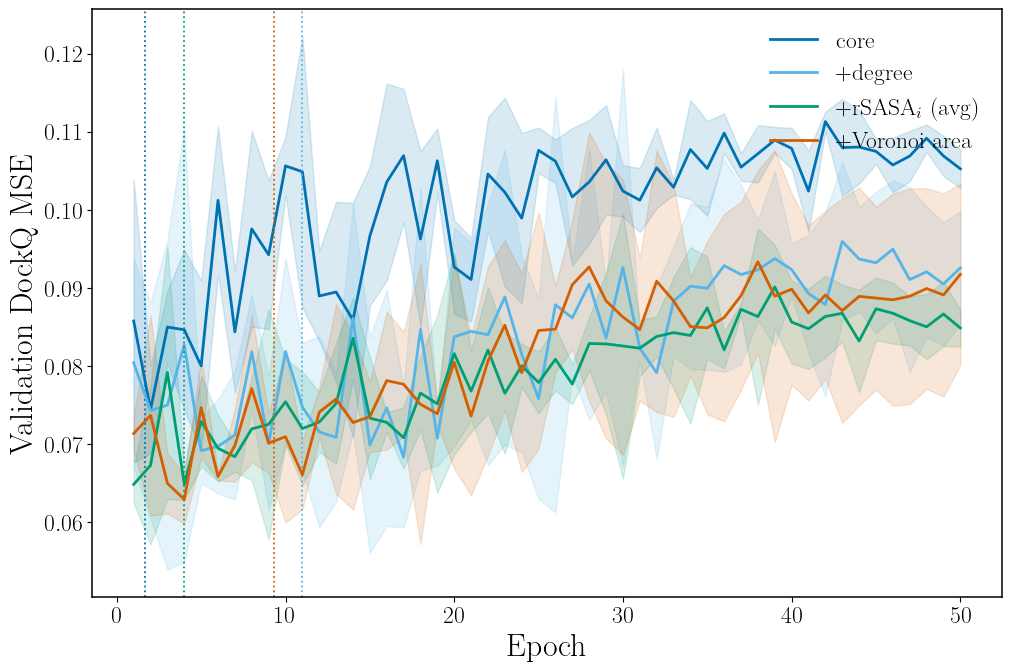

In [4]:
fig, ax = plt.subplots(figsize=(10, 6.6), constrained_layout=True)
for rung in RUNGS:
    g = history[history.rung == rung].groupby('epoch').val_target_mse.agg(['mean', 'std'])
    ax.plot(g.index, g['mean'], color=RUNG_COLOR[rung], lw=2, label=RUNG_LABEL[rung])
    ax.fill_between(g.index, g['mean'] - g['std'], g['mean'] + g['std'], color=RUNG_COLOR[rung], alpha=.15)
    mean_best_epoch = best.loc[best.rung == rung, 'best_epoch'].mean()
    ax.axvline(mean_best_epoch, color=RUNG_COLOR[rung], ls=':', lw=1.3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation DockQ MSE')
ax.legend(frameon=False, loc='upper right')
save(fig, 'convergence')

## Reconstruction quality by rung

Mean across the three seeds for a few reconstruction metrics most relevant to what each rung adds: amino-acid
identity and edge-presence recovery (features present from `core` onward), the C$\alpha$-distance error
(`ca_dist` is an input/reconstruction target in every rung), and the rSASA$_i$ mean absolute error (only
meaningful from `rsasa` onward, where the graph-average feature is actually present as a node input).

aa_identity_accuracy_pct          edge_f1_pct           \
                            mean      std        mean      std   
rung                                                             
core                     91.0416   9.3126     46.9224  20.0825   
degree                   81.8754  24.1064     73.4238  13.1750   
rsasa                    62.6393  31.2131     50.6797  36.1502   
voronoi                  94.5725   3.7255     78.6859   3.2671   

        ca_dist_mae_angstrom         rsasa_i_mae          
                        mean     std        mean     std  
rung                                                      
core                  1.6709  0.0167         NaN     NaN  
degree                1.3474  0.2816         NaN     NaN  
rsasa                 1.6147  0.1924      0.0642  0.0101  
voronoi               1.4294  0.2545      0.0593  0.0072

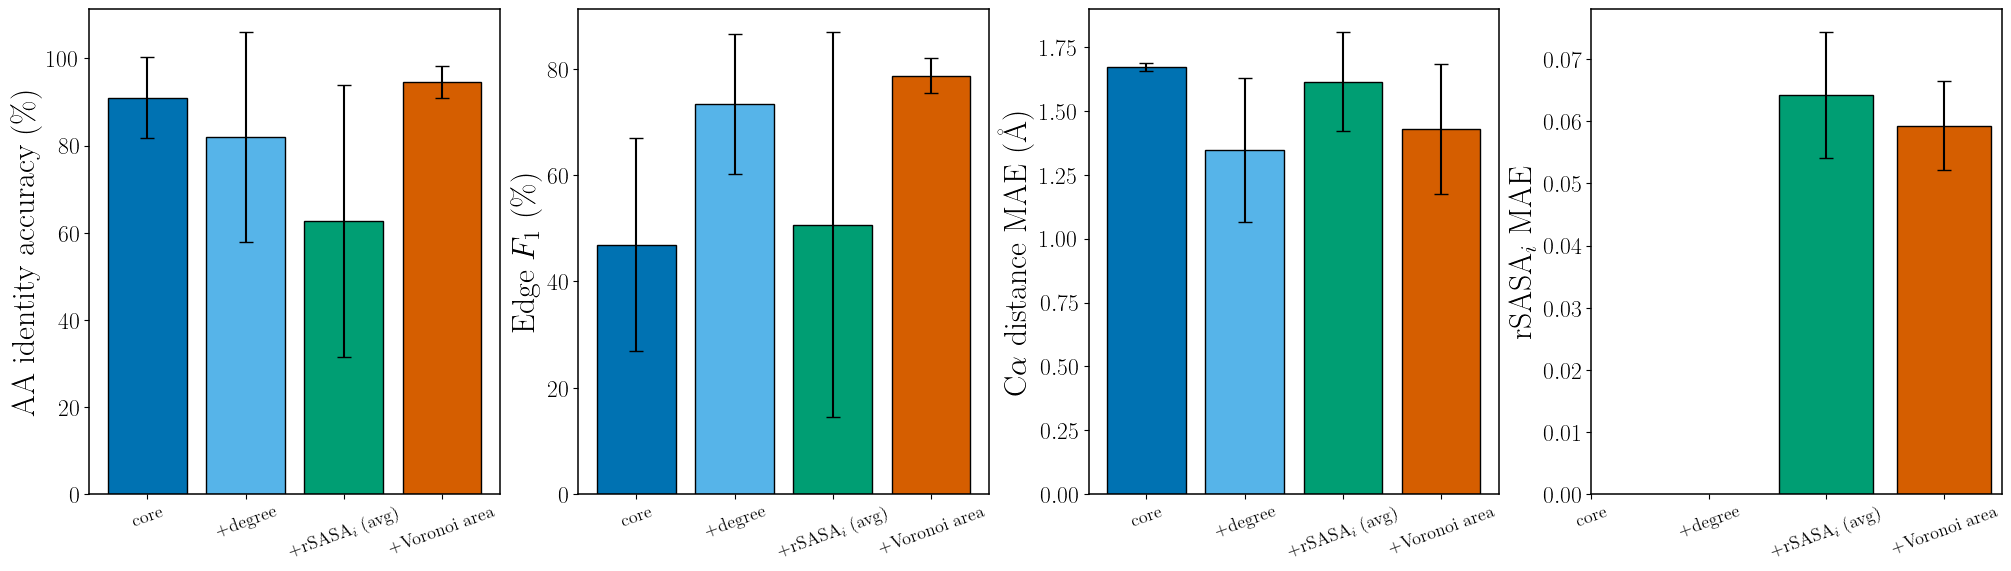

In [5]:
recon_cols = ['aa_identity_accuracy_pct', 'edge_f1_pct', 'ca_dist_mae_angstrom', 'rsasa_i_mae']
RECON_LABEL = {'aa_identity_accuracy_pct': 'AA identity accuracy (\\%)', 'edge_f1_pct': 'Edge $F_1$ (\\%)',
               'ca_dist_mae_angstrom': r'C$\alpha$ distance MAE (\AA)', 'rsasa_i_mae': 'rSASA$_i$ MAE'}
recon = summary.groupby('rung')[recon_cols].agg(['mean', 'std']).loc[RUNGS]
display(recon.round(4))
recon.to_csv(EXPORT / 'reconstruction_by_rung.csv')

fig, axes = plt.subplots(1, len(recon_cols), figsize=(5 * len(recon_cols), 5.6), constrained_layout=True)
for ax, col in zip(axes, recon_cols):
    values = recon[(col, 'mean')].to_numpy(); errors = recon[(col, 'std')].fillna(0).to_numpy()
    ax.bar(x, values, color=[RUNG_COLOR[r] for r in RUNGS], edgecolor='black', yerr=errors, capsize=5)
    ax.set_xticks(x, labels, fontsize=13, rotation=20)
    ax.set_ylabel(RECON_LABEL[col])
save(fig, 'reconstruction_by_rung')

## Dissertation figure: DockQ performance and reconstruction quality together

The two headline DockQ metrics (left) alongside three reconstruction-quality metrics (right), all on the same
four-rung ladder. The point this figure is built to make: `voronoi` is roughly flat against `rsasa` on DockQ
MSE and $\rho$ (it does not clearly win), but going `rsasa` $\to$ `voronoi` **uniformly** improves every
reconstruction metric shown -- and sharply tightens the seed-to-seed spread, which `rsasa` alone does not
(amino-acid identity accuracy std across seeds: 31.2 percentage points at `rsasa` vs. 3.7 at `voronoi`; edge
$F_1$ std: 36.2 vs. 3.3). Voronoi contact area does not clearly help the downstream DockQ regression on this
10% subset, but it makes the autoencoder's own structural reconstruction both better on average and far more
reliable across seeds -- a result worth reporting on its own terms, independent of the DockQ number.

Grayscale, darkest at `voronoi`, so it reproduces in print. Seed dots are drawn white-on-black so they stay
visible against the darkest bars.

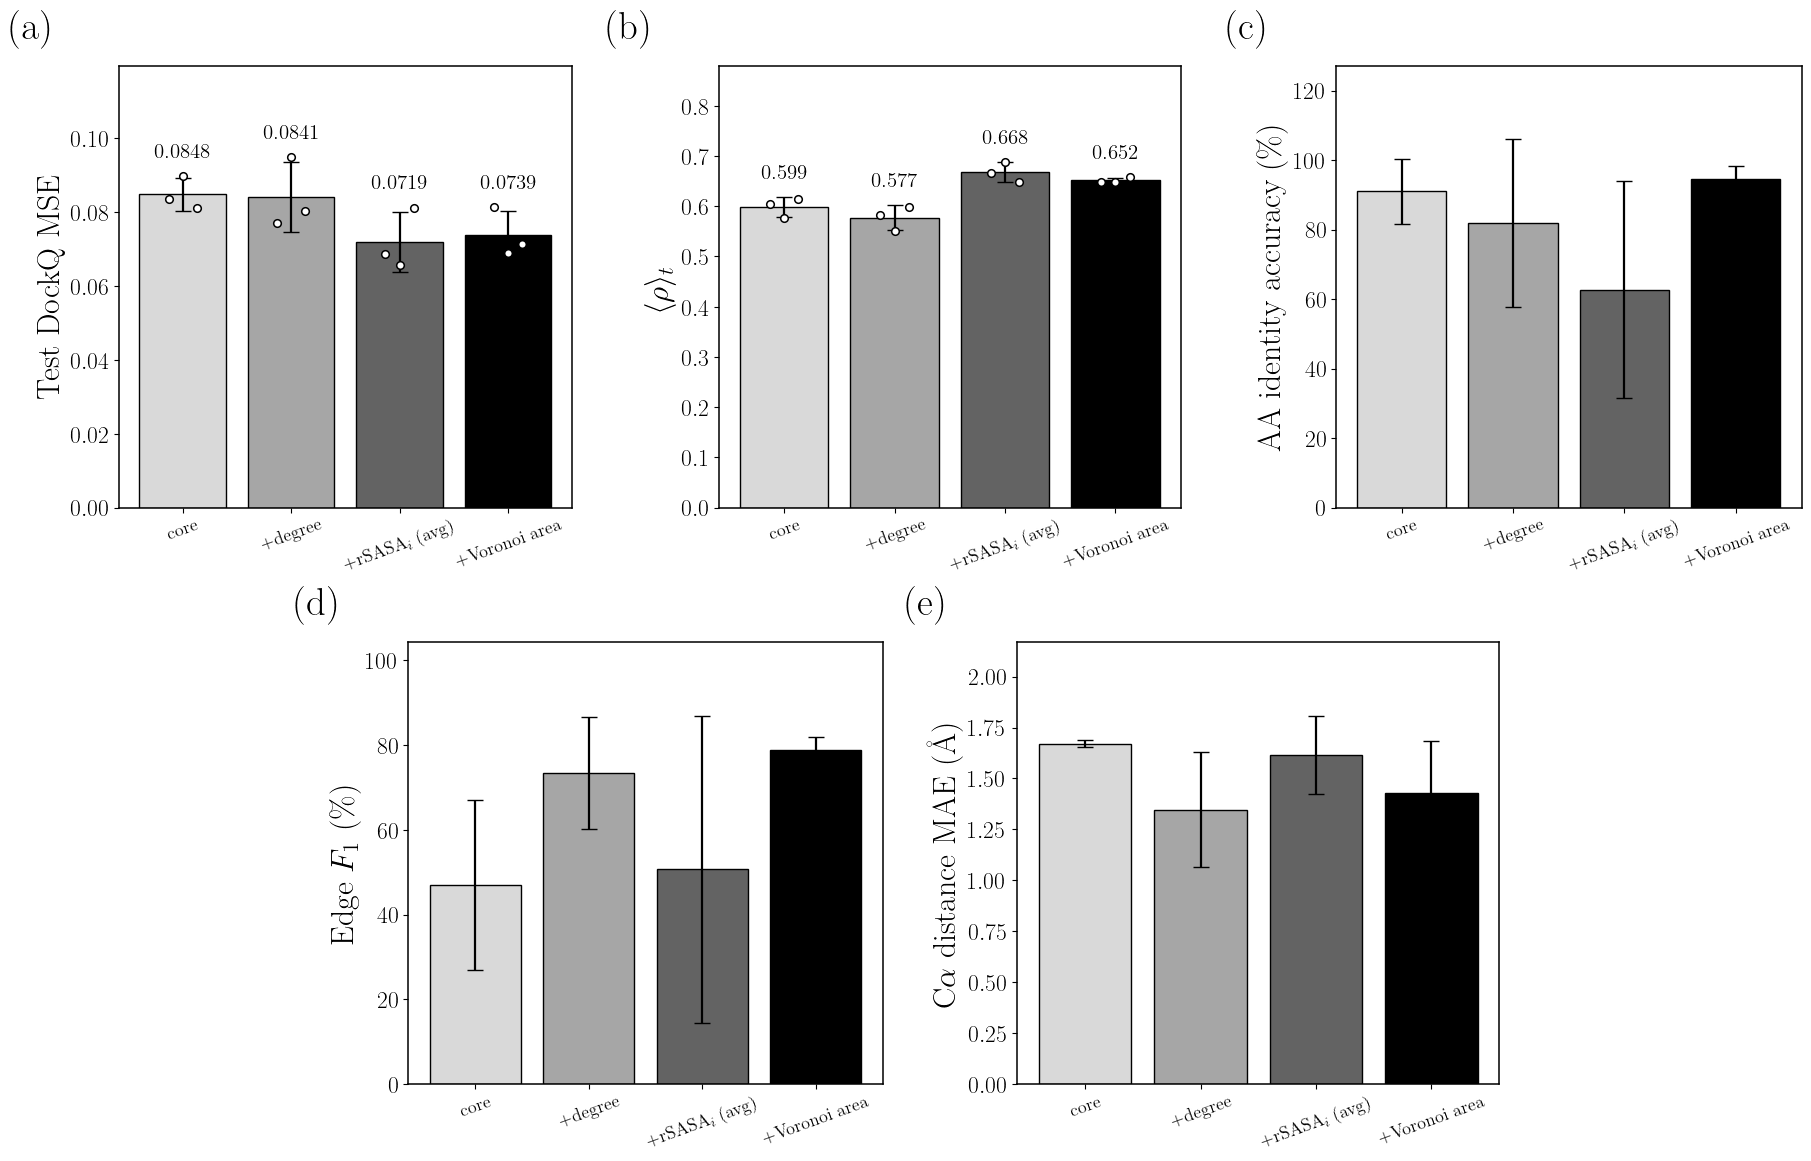

In [6]:
GRAY = {'core': '#d9d9d9', 'degree': '#a6a6a6', 'rsasa': '#636363', 'voronoi': '#000000'}

fig = plt.figure(figsize=(18, 11.5))
gs = fig.add_gridspec(2, 6)
axes = [fig.add_subplot(gs[0, 0:2]), fig.add_subplot(gs[0, 2:4]), fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]
fig.set_constrained_layout(True)
PANEL_LABEL = ['(a)', '(b)', '(c)', '(d)', '(e)']

def panel_label(ax, label):
    ax.text(-0.14, 1.04, label, transform=ax.transAxes, fontsize=28, fontweight='bold', va='bottom', ha='right')

dockq_specs = [
    (axes[0], agg['mean_mse'], agg['sd_mse'], 'test_target_mse', 'Test DockQ MSE', '%.4f'),
    (axes[1], agg['mean_rho'], agg['sd_rho'], 'macro_rho', r'$\langle\rho\rangle_t$', '%.3f'),
]
for ax, values, errors, run_col, ylabel, fmt in dockq_specs:
    values = values.to_numpy(); errors = errors.to_numpy()
    top = (values + errors).max()
    ax.bar(x, values, color=[GRAY[r] for r in RUNGS], edgecolor='black', yerr=errors, capsize=6,
           error_kw=dict(lw=1.6))
    for i, r in enumerate(RUNGS):
        seed_values = best.loc[best.rung == r, run_col].to_numpy()
        ax.scatter(i + np.linspace(-.13, .13, len(seed_values)), seed_values,
                   facecolors='white', edgecolors='black', linewidths=1.1, s=30, zorder=6)
        ax.text(i, max(values[i] + errors[i], seed_values.max()) + .055 * top, fmt % values[i],
                ha='center', fontsize=15)
    ax.set_xticks(x, labels, fontsize=13, rotation=20); ax.set_ylabel(ylabel)
    ax.set_ylim(0, top * 1.28)

for ax, col in zip(axes[2:5], recon_cols[:3]):
    values = recon[(col, 'mean')].to_numpy(); errors = recon[(col, 'std')].fillna(0).to_numpy()
    top = (values + errors).max()
    ax.bar(x, values, color=[GRAY[r] for r in RUNGS], edgecolor='black', yerr=errors, capsize=6,
           error_kw=dict(lw=1.6))
    ax.set_xticks(x, labels, fontsize=13, rotation=20); ax.set_ylabel(RECON_LABEL[col])
    ax.set_ylim(0, top * 1.2)

for ax, label in zip(axes[:5], PANEL_LABEL):
    panel_label(ax, label)

save(fig, 'dissertation_ladder_figure')

## Limitations

- Every reported test-split number is read off at the epoch selected by minimum validation `target_mse` -- a
  best-of-50 statistic on one split per run, not an independently chosen stopping point.
- Three seeds give a crude variance estimate; no significance test is reported here, and the gap between
  adjacent rungs is often comparable to the seed-to-seed spread within a rung.
- This is the 10% stratified subset, not the full ~189k-model cohort; absolute numbers (and possibly rung
  ordering) need not transfer to the full-dataset run.
- The `rsasa` and `voronoi` rungs here use the graph-level average `rsasa_i`, not a genuine per-node value --
  any apparent benefit (or lack of one) from "adding rSASA" in this notebook reflects that weaker feature, not
  the corrected `rsasa_i_node`.
- There is no electrostatics rung in this run. It cannot be compared against anything here; it only exists in
  the corrected 5-rung ladder.